In [1]:
# Import standard libraries
import os
import random
from pathlib import Path

# Data manipulation
import numpy as np
import pandas as pd

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Deep Learning
import tensorflow as tf

# Model evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# -------------------------------
# Set Random Seed for Reproducibility
# -------------------------------
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

os.environ["PYTHONHASHSEED"] = str(SEED)
os.environ["TF_DETERMINISTIC_OPS"] = "1"

# -------------------------------
# Display Environment Information
# -------------------------------
print("=" * 50)
print(f"TensorFlow Version : {tf.__version__}")
print(f"Random Seed        : {SEED}")

gpus = tf.config.list_physical_devices("GPU")

if gpus:
    print(f"GPU Available      : Yes ({len(gpus)} detected)")
    print(f"GPU Device         : {gpus[0].name}")
else:
    print("GPU Available      : No (Running on CPU)")

print("=" * 50)

TensorFlow Version : 2.20.0
Random Seed        : 42
GPU Available      : Yes (2 detected)
GPU Device         : /physical_device:GPU:0


## Step 3: Create the Results Directory

Throughout this project, various outputs such as training curves, evaluation plots, confusion matrices, and the trained model will be saved for future reference. This step creates a dedicated results directory if it does not already exist, ensuring that all generated files are organized in one location.

In [2]:
# -----------------------------------
# Create Results Directory
# -----------------------------------

from pathlib import Path

# Directory where all outputs will be saved
results_dir = Path("results")

# Create the directory if it doesn't already exist
results_dir.mkdir(parents=True, exist_ok=True)

print(f"Results directory created at: {results_dir.resolve()}")

Results directory created at: /kaggle/working/results


In [3]:
from pathlib import Path

input_dir = Path("/kaggle/input")

for path in input_dir.iterdir():
    print(path)

/kaggle/input/datasets


In [4]:
from pathlib import Path

dataset_root = Path("/kaggle/input/datasets")

for item in dataset_root.iterdir():
    print(item)

/kaggle/input/datasets/tushar5harma


In [5]:
from pathlib import Path

dataset_path = Path("/kaggle/input/datasets/tushar5harma")

for item in dataset_path.iterdir():
    print(item)

/kaggle/input/datasets/tushar5harma/plant-village-dataset-updated


## Step 4: Verify the Dataset Structure

Before preprocessing the dataset, it is important to inspect its directory structure. This confirms that the dataset has been loaded correctly into the Kaggle environment and helps determine whether any additional preprocessing, such as renaming folders or copying files, is required.

In [6]:
from pathlib import Path

# Kaggle dataset path
dataset_path = Path("/kaggle/input/datasets/tushar5harma/plant-village-dataset-updated")

print("Contents of the dataset:\n")

for item in dataset_path.iterdir():
    print(item)

Contents of the dataset:

/kaggle/input/datasets/tushar5harma/plant-village-dataset-updated/Tomato
/kaggle/input/datasets/tushar5harma/plant-village-dataset-updated/Apple
/kaggle/input/datasets/tushar5harma/plant-village-dataset-updated/Bell Pepper
/kaggle/input/datasets/tushar5harma/plant-village-dataset-updated/Strawberry
/kaggle/input/datasets/tushar5harma/plant-village-dataset-updated/Corn (Maize)
/kaggle/input/datasets/tushar5harma/plant-village-dataset-updated/Peach
/kaggle/input/datasets/tushar5harma/plant-village-dataset-updated/Grape
/kaggle/input/datasets/tushar5harma/plant-village-dataset-updated/Cherry
/kaggle/input/datasets/tushar5harma/plant-village-dataset-updated/Potato


In [7]:
from pathlib import Path

apple_path = Path("/kaggle/input/datasets/tushar5harma/plant-village-dataset-updated/Apple")

for item in apple_path.iterdir():
    print(item)

/kaggle/input/datasets/tushar5harma/plant-village-dataset-updated/Apple/Val
/kaggle/input/datasets/tushar5harma/plant-village-dataset-updated/Apple/Test
/kaggle/input/datasets/tushar5harma/plant-village-dataset-updated/Apple/Train


In [8]:
from pathlib import Path

train_path = Path("/kaggle/input/datasets/tushar5harma/plant-village-dataset-updated/Apple/Train")

for item in train_path.iterdir():
    print(item)

/kaggle/input/datasets/tushar5harma/plant-village-dataset-updated/Apple/Train/Healthy
/kaggle/input/datasets/tushar5harma/plant-village-dataset-updated/Apple/Train/Apple Scab
/kaggle/input/datasets/tushar5harma/plant-village-dataset-updated/Apple/Train/Cedar Apple Rust
/kaggle/input/datasets/tushar5harma/plant-village-dataset-updated/Apple/Train/Black Rot


## Step 5: Prepare the PlantVillage Dataset

The downloaded PlantVillage dataset is organised by plant species, with separate **Train**, **Validation**, and **Test** folders for each plant. However, for image classification, it is more convenient to organise the dataset into a single directory structure where each class represents a unique combination of the plant species and disease.

In this step, the dataset is reorganised into a new directory containing unified class labels such as **Apple_Healthy**, **Apple_Black_Rot**, and **Tomato_Late_Blight**. The reorganised dataset is stored in the Kaggle working directory and will be used throughout the remainder of the project.

In [9]:
# -----------------------------------
# STEP 5: Define Dataset Paths
# -----------------------------------

from pathlib import Path
import shutil

# Original dataset (Read Only)
base_input = Path(
    "/kaggle/input/datasets/tushar5harma/plant-village-dataset-updated"
)

# New dataset (Writable)
base_output = Path("/kaggle/working/PlantVillage_Dataset_Renamed")

# Create output directory
base_output.mkdir(parents=True, exist_ok=True)

print(f"Input Dataset : {base_input}")
print(f"Output Folder : {base_output}")

Input Dataset : /kaggle/input/datasets/tushar5harma/plant-village-dataset-updated
Output Folder : /kaggle/working/PlantVillage_Dataset_Renamed


In [10]:
# -----------------------------------
# STEP 6: Reorganize Dataset
# -----------------------------------

splits = ["Train", "Val", "Test"]

total_images = 0

for plant_dir in base_input.iterdir():

    if not plant_dir.is_dir():
        continue

    plant = plant_dir.name

    for split in splits:

        split_path = plant_dir / split

        if not split_path.exists():
            print(f"Missing split: {split_path}")
            continue

        for disease_dir in split_path.iterdir():

            if not disease_dir.is_dir():
                continue

            disease = disease_dir.name

            # Create class label
            class_name = f"{plant}_{disease}"

            destination = (
                base_output
                / split.lower()
                / class_name
            )

            destination.mkdir(parents=True, exist_ok=True)

            for image_file in disease_dir.iterdir():

                if image_file.is_file():

                    shutil.copy(
                        image_file,
                        destination / image_file.name
                    )

                    total_images += 1

print("=" * 50)
print("Dataset successfully reorganized!")
print(f"Total images copied : {total_images:,}")
print(f"Saved to            : {base_output}")
print("=" * 50)

Dataset successfully reorganized!
Total images copied : 67,111
Saved to            : /kaggle/working/PlantVillage_Dataset_Renamed


In [11]:
# -----------------------------------
# STEP 7: Configure Dataset Paths
# -----------------------------------

BASE_DIR = base_output

train_dir = BASE_DIR / "train"
val_dir = BASE_DIR / "val"
test_dir = BASE_DIR / "test"

print("=" * 50)
print("Dataset Directories")
print("=" * 50)
print(f"Train      : {train_dir}")
print(f"Validation : {val_dir}")
print(f"Test       : {test_dir}")
print("=" * 50)

Dataset Directories
Train      : /kaggle/working/PlantVillage_Dataset_Renamed/train
Validation : /kaggle/working/PlantVillage_Dataset_Renamed/val
Test       : /kaggle/working/PlantVillage_Dataset_Renamed/test


In [12]:
# -----------------------------------
# Project Directories
# -----------------------------------

results_dir = Path("/kaggle/working/results/lab7")
artifacts_dir = Path("/kaggle/working/artifacts")
models_dir = Path("/kaggle/working/models")

results_dir.mkdir(parents=True, exist_ok=True)
artifacts_dir.mkdir(parents=True, exist_ok=True)
models_dir.mkdir(parents=True, exist_ok=True)

In [13]:
# -----------------------------------
# STEP 8: Verify Dataset Directories
# -----------------------------------

dataset_dirs = {
    "Train": train_dir,
    "Validation": val_dir,
    "Test": test_dir
}

print("=" * 65)
print(f"{'Split':<12}{'Exists':<10}{'Number of Images'}")
print("=" * 65)

for split, directory in dataset_dirs.items():

    exists = directory.exists()

    image_count = (
        len(list(directory.rglob("*.jpg"))) +
        len(list(directory.rglob("*.jpeg"))) +
        len(list(directory.rglob("*.png")))
    ) if exists else 0

    print(f"{split:<12}{str(exists):<10}{image_count:,}")

print("=" * 65)

Split       Exists    Number of Images
Train       True      2,428
Validation  True      531
Test        True      60


## Step 9: Define Model Hyperparameters

This step defines the key hyperparameters that control the training process. These include the image size, batch size, number of training epochs, and learning rate. Selecting appropriate hyperparameters helps balance training speed, memory usage, and model performance.

For this project, images are resized to **128 × 128 pixels**, a batch size of **64** is used for efficient GPU utilization, and the model is allowed to train for a maximum of **20 epochs**. Early stopping will automatically terminate training if the model stops improving, reducing unnecessary computation and helping to prevent overfitting.

In [14]:
# -----------------------------------
# STEP 9: Define Hyperparameters
# -----------------------------------

# Image dimensions
IMAGE_HEIGHT = 128
IMAGE_WIDTH = 128
IMAGE_SIZE = (IMAGE_HEIGHT, IMAGE_WIDTH)

# Training parameters
BATCH_SIZE = 64
EPOCHS = 20
LEARNING_RATE = 1e-3

print("=" * 50)
print("Training Configuration")
print("=" * 50)
print(f"Image Size     : {IMAGE_HEIGHT} × {IMAGE_WIDTH}")
print(f"Batch Size     : {BATCH_SIZE}")
print(f"Epochs         : {EPOCHS}")
print(f"Learning Rate  : {LEARNING_RATE}")
print("=" * 50)

Training Configuration
Image Size     : 128 × 128
Batch Size     : 64
Epochs         : 20
Learning Rate  : 0.001


## Step 10: Load the Training Dataset

In this step, TensorFlow loads the reorganised training dataset from the training directory. Images are automatically resized to **128 × 128 pixels**, grouped into batches, and assigned labels based on their parent folder names.

The dataset is shuffled before training to ensure that the model learns from randomly ordered samples, reducing the risk of learning unintended patterns from the data order.

In [15]:
# -----------------------------------
# STEP 10: Load Training Dataset
# -----------------------------------

train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    seed=SEED,
    shuffle=True,
    label_mode="int"
)

print("=" * 50)
print("Training Dataset Loaded Successfully")
print("=" * 50)
print(f"Number of Classes : {len(train_dataset.class_names)}")
print(f"Batch Size        : {BATCH_SIZE}")
print(f"Image Size        : {IMAGE_SIZE}")
print("=" * 50)

Found 53690 files belonging to 29 classes.


I0000 00:00:1784198331.448491      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1784198331.451576      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Training Dataset Loaded Successfully
Number of Classes : 29
Batch Size        : 64
Image Size        : (128, 128)


## Step 11: Load the Validation Dataset

The validation dataset is used to monitor the model's performance during training. Unlike the training dataset, the validation images are **not shuffled** because they are only used to evaluate how well the model generalises to unseen data after each training epoch.

In [16]:
# -----------------------------------
# STEP 11: Load Validation Dataset
# -----------------------------------

val_dataset = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    seed=SEED,
    shuffle=False,
    label_mode="int"
)

print("=" * 50)
print("Validation Dataset Loaded Successfully")
print("=" * 50)
print(f"Validation Classes : {len(val_dataset.class_names)}")
print("=" * 50)

Found 12067 files belonging to 29 classes.
Validation Dataset Loaded Successfully
Validation Classes : 29


In [17]:
# -----------------------------------
# STEP 12: Load Test Dataset
# -----------------------------------

test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    seed=SEED,
    shuffle=False,
    label_mode="int"
)

print("=" * 50)
print("Test Dataset Loaded Successfully")
print("=" * 50)
print(f"Test Classes : {len(test_dataset.class_names)}")
print("=" * 50)

Found 1354 files belonging to 29 classes.
Test Dataset Loaded Successfully
Test Classes : 29


## Step 13: Retrieve and Save the Class Labels

TensorFlow automatically assigns a numerical index to each class based on the names of the subdirectories in the training dataset. These class labels define the output classes of the deep learning models.

To support future deployment, the class labels are also saved as a **JSON** file. This ensures that the Streamlit application can correctly translate the model's predicted class indices into meaningful plant disease names during inference.

In [18]:
# -----------------------------------
# STEP 13: Get and Save Class Labels
# -----------------------------------

import json

# Retrieve class names
class_names = train_dataset.class_names
num_classes = len(class_names)

print("=" * 60)
print(f"Number of Classes : {num_classes}")
print("=" * 60)

for i, class_name in enumerate(class_names):
    print(f"{i:2d} : {class_name}")

print("=" * 60)

# Save class names for deployment
class_file = artifacts_dir / "class_names.json"

with open(class_file, "w") as f:
    json.dump(class_names, f, indent=4)

print(f"\nClass labels saved to:\n{class_file}")

Number of Classes : 29
 0 : Apple_Apple Scab
 1 : Apple_Black Rot
 2 : Apple_Cedar Apple Rust
 3 : Apple_Healthy
 4 : Bell Pepper_Bacterial Spot
 5 : Bell Pepper_Healthy
 6 : Cherry_Healthy
 7 : Cherry_Powdery Mildew
 8 : Corn (Maize)_Cercospora Leaf Spot
 9 : Corn (Maize)_Common Rust 
10 : Corn (Maize)_Healthy
11 : Corn (Maize)_Northern Leaf Blight
12 : Grape_Black Rot
13 : Grape_Esca (Black Measles)
14 : Grape_Healthy
15 : Grape_Leaf Blight
16 : Peach_Bacterial Spot
17 : Peach_Healthy
18 : Potato_Early Blight
19 : Potato_Healthy
20 : Potato_Late Blight
21 : Strawberry_Healthy
22 : Strawberry_Leaf Scorch
23 : Tomato_Bacterial Spot
24 : Tomato_Early Blight
25 : Tomato_Healthy
26 : Tomato_Late Blight
27 : Tomato_Septoria Leaf Spot
28 : Tomato_Yellow Leaf Curl Virus

Class labels saved to:
/kaggle/working/artifacts/class_names.json


In [19]:
# -----------------------------------
# STEP 13: Get and Save Class Labels
# -----------------------------------

import json

# Retrieve class names
class_names = train_dataset.class_names
num_classes = len(class_names)

print("=" * 60)
print(f"Number of Classes : {num_classes}")
print("=" * 60)

for i, class_name in enumerate(class_names):
    print(f"{i:2d} : {class_name}")

print("=" * 60)

# -----------------------------------
# Save Class Names
# -----------------------------------

class_file = artifacts_dir / "class_names.json"

with open(class_file, "w") as f:
    json.dump(class_names, f, indent=4)

# -----------------------------------
# Save Model Metadata
# -----------------------------------

metadata = {
    "dataset": "PlantVillage Dataset",
    "num_classes": num_classes,
    "class_names_file": "class_names.json",
    "image_height": IMAGE_HEIGHT,
    "image_width": IMAGE_WIDTH,
    "batch_size": BATCH_SIZE,
    "learning_rate": LEARNING_RATE,
    "seed": SEED,
    "framework": "TensorFlow",
    "tensorflow_version": tf.__version__
}

metadata_file = artifacts_dir / "model_metadata.json"

with open(metadata_file, "w") as f:
    json.dump(metadata, f, indent=4)

print(f"\nClass labels saved to : {class_file}")
print(f"Metadata saved to     : {metadata_file}")

Number of Classes : 29
 0 : Apple_Apple Scab
 1 : Apple_Black Rot
 2 : Apple_Cedar Apple Rust
 3 : Apple_Healthy
 4 : Bell Pepper_Bacterial Spot
 5 : Bell Pepper_Healthy
 6 : Cherry_Healthy
 7 : Cherry_Powdery Mildew
 8 : Corn (Maize)_Cercospora Leaf Spot
 9 : Corn (Maize)_Common Rust 
10 : Corn (Maize)_Healthy
11 : Corn (Maize)_Northern Leaf Blight
12 : Grape_Black Rot
13 : Grape_Esca (Black Measles)
14 : Grape_Healthy
15 : Grape_Leaf Blight
16 : Peach_Bacterial Spot
17 : Peach_Healthy
18 : Potato_Early Blight
19 : Potato_Healthy
20 : Potato_Late Blight
21 : Strawberry_Healthy
22 : Strawberry_Leaf Scorch
23 : Tomato_Bacterial Spot
24 : Tomato_Early Blight
25 : Tomato_Healthy
26 : Tomato_Late Blight
27 : Tomato_Septoria Leaf Spot
28 : Tomato_Yellow Leaf Curl Virus

Class labels saved to : /kaggle/working/artifacts/class_names.json
Metadata saved to     : /kaggle/working/artifacts/model_metadata.json


In [20]:
# -----------------------------------
# STEP 15: Capture a Fixed Batch
# -----------------------------------

for images, labels in train_dataset.take(1):
    fixed_images = images.numpy()
    fixed_labels = labels.numpy()

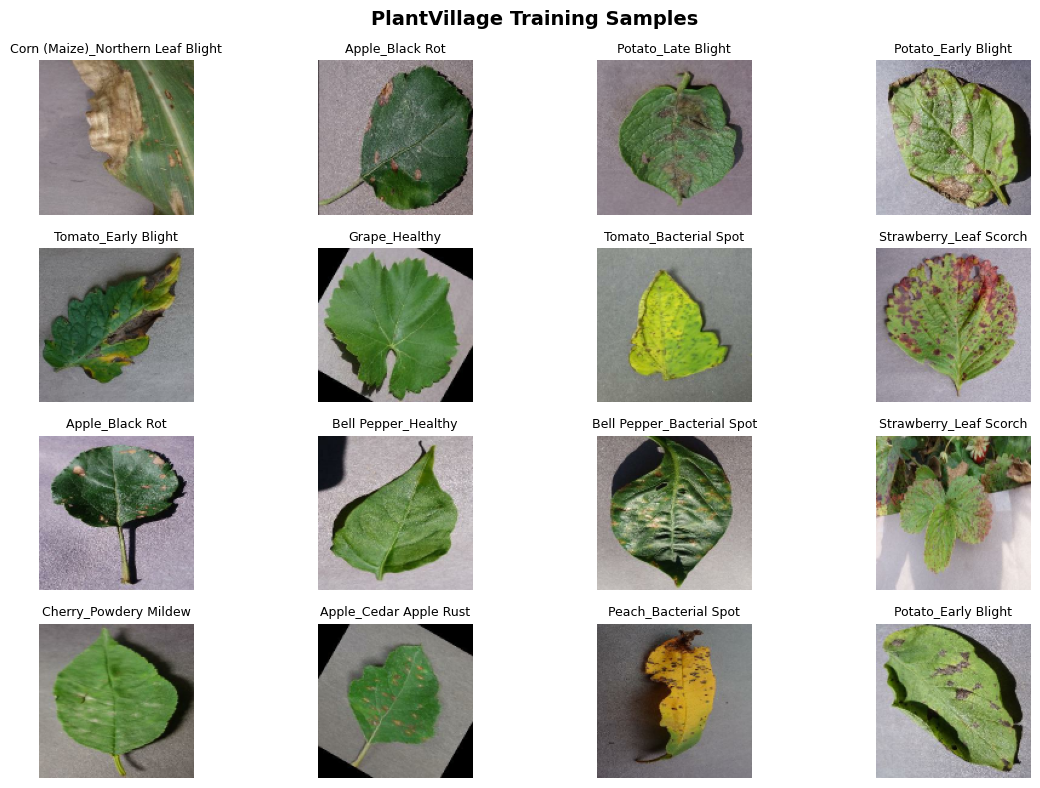

Figure saved to:
/kaggle/working/results/lab7/training_samples.png


In [21]:
# -----------------------------------
# STEP 15: Display Sample Images
# -----------------------------------

plt.figure(figsize=(12, 8))

for i in range(min(16, len(fixed_images))):

    plt.subplot(4, 4, i + 1)

    plt.imshow(fixed_images[i].astype("uint8"))

    plt.title(
        class_names[fixed_labels[i]],
        fontsize=9
    )

    plt.axis("off")

plt.suptitle(
    "PlantVillage Training Samples",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()

# Save figure
sample_image_path = results_dir / "training_samples.png"

plt.savefig(
    sample_image_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Figure saved to:\n{sample_image_path}")

In [22]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = (
    train_dataset
    .shuffle(1000, seed=SEED)
    .prefetch(AUTOTUNE)
)

val_dataset = val_dataset.prefetch(AUTOTUNE)
test_dataset = test_dataset.prefetch(AUTOTUNE)

## Step 17: Create the Data Augmentation Pipeline

Data augmentation is a preprocessing technique used to artificially increase the diversity of the training dataset by applying random transformations to the input images. This helps the model generalize better to unseen data and reduces the risk of overfitting.

In this project, the following augmentation techniques are applied during training:

- **Random Horizontal Flip** – Simulates different viewing orientations.
- **Random Rotation** – Rotates images by a small random angle.
- **Random Zoom** – Randomly zooms into the image while preserving its content.

These transformations are applied **only during training**. The validation and test datasets remain unchanged to provide an unbiased evaluation of model performance.

In [23]:
# -----------------------------------
# STEP 17: Data Augmentation Pipeline
# -----------------------------------

data_augmentation = tf.keras.Sequential(
    [
        tf.keras.layers.RandomFlip("horizontal"),
        tf.keras.layers.RandomRotation(0.2),
        tf.keras.layers.RandomZoom(0.2),
    ],
    name="data_augmentation"
)

print("✓ Data augmentation pipeline created successfully.")

✓ Data augmentation pipeline created successfully.


## Step 18: Visualize the Effect of Data Augmentation

Before training the convolutional neural network, it is useful to examine how the data augmentation pipeline transforms input images. The augmented images retain the essential disease characteristics while introducing controlled variations such as flipping, rotation, and zooming.

These transformations improve the model's ability to generalize to new images captured under different environmental conditions and viewing angles.

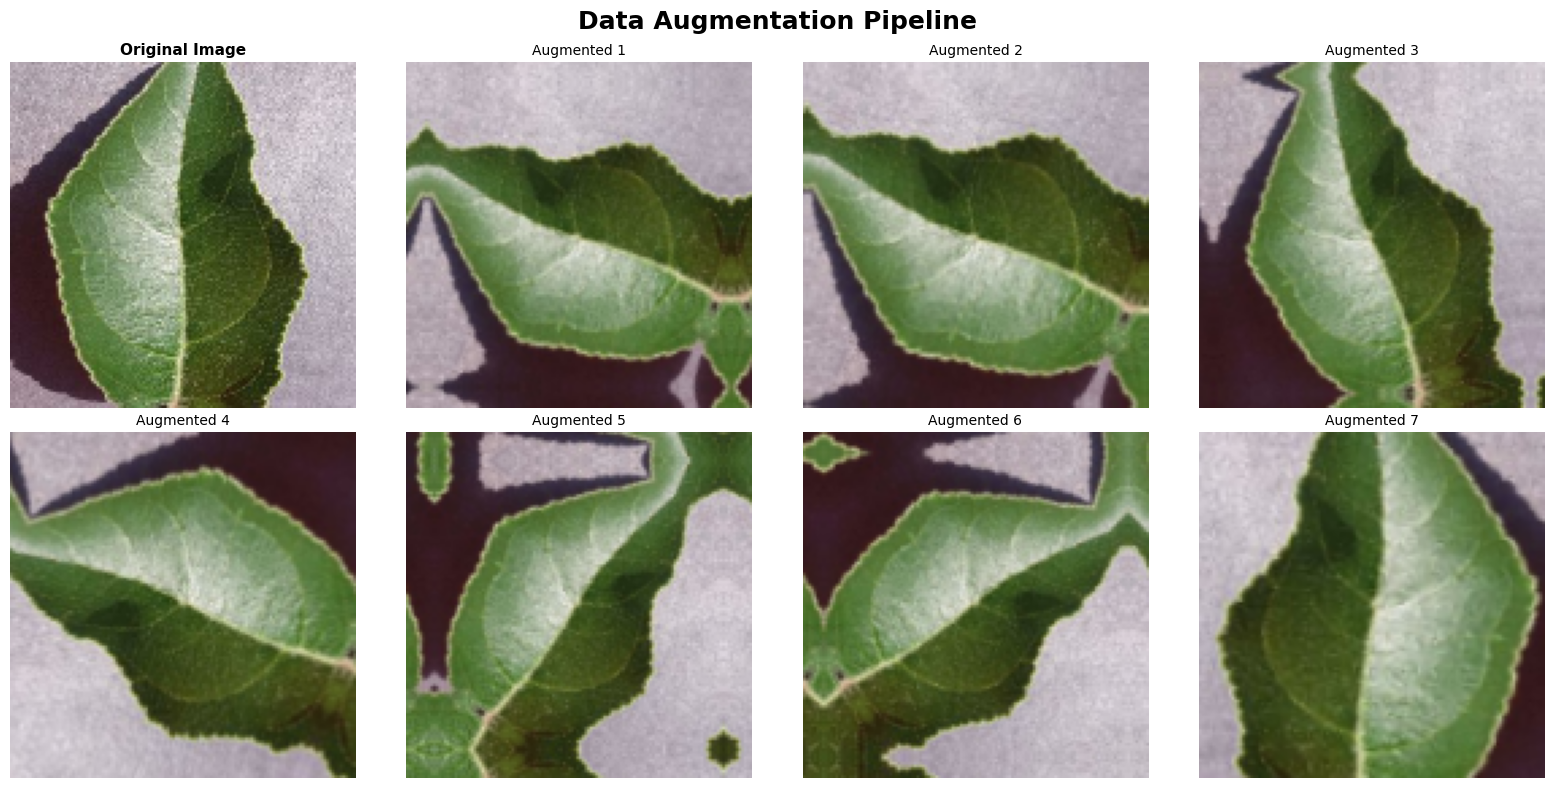

Figure saved to:
/kaggle/working/results/lab7/data_augmentation_examples.png


In [24]:
# -----------------------------------
# STEP 18: Visualize Data Augmentation
# -----------------------------------

# Get one sample image
for images, _ in train_dataset.take(1):
    sample_image = images[0:1]
    break

# Create figure
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

axes = axes.flatten()

# Original image
axes[0].imshow(sample_image[0].numpy().astype("uint8"))
axes[0].set_title(
    "Original Image",
    fontsize=11,
    fontweight="bold"
)
axes[0].axis("off")

# Augmented images
for i in range(1, 8):

    augmented = data_augmentation(
        sample_image,
        training=True
    )[0].numpy().astype("uint8")

    axes[i].imshow(augmented)

    axes[i].set_title(
        f"Augmented {i}",
        fontsize=10
    )

    axes[i].axis("off")

plt.suptitle(
    "Data Augmentation Pipeline",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()

# Save high-quality figure
augmentation_path = results_dir / "data_augmentation_examples.png"

plt.savefig(
    augmentation_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Figure saved to:\n{augmentation_path}")

In [25]:
# -----------------------------------
# STEP 19: Shared Callbacks & Utilities
# -----------------------------------

import os

# Create models directory
models_dir.mkdir(parents=True, exist_ok=True)


# ============================================================
# CALLBACKS
# ============================================================

def make_callbacks(name):
    """
    Return a fresh set of callbacks for each model.
    """

    return [

        tf.keras.callbacks.ModelCheckpoint(
            filepath=models_dir / f"{name}_best.keras",
            monitor="val_accuracy",
            save_best_only=True,
            verbose=1
        ),

        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=8,
            restore_best_weights=True,
            verbose=1
        ),

        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.3,
            patience=4,
            min_lr=1e-7,
            verbose=1
        )

    ]


# ============================================================
# LEARNING CURVES
# ============================================================

def plot_learning_curves(history, title="Learning Curves"):
    """
    Plot training and validation learning curves.
    """

    acc = history.history["accuracy"]
    val_acc = history.history["val_accuracy"]

    loss = history.history["loss"]
    val_loss = history.history["val_loss"]

    epochs_range = range(1, len(acc) + 1)

    plt.figure(figsize=(14, 5))

    # Accuracy
    plt.subplot(1, 2, 1)

    plt.plot(
        epochs_range,
        acc,
        linewidth=2,
        label="Training"
    )

    plt.plot(
        epochs_range,
        val_acc,
        "--",
        linewidth=2,
        label="Validation"
    )

    plt.title(f"{title} - Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.grid(alpha=0.3)
    plt.legend()

    # Loss
    plt.subplot(1, 2, 2)

    plt.plot(
        epochs_range,
        loss,
        linewidth=2,
        label="Training"
    )

    plt.plot(
        epochs_range,
        val_loss,
        "--",
        linewidth=2,
        label="Validation"
    )

    plt.title(f"{title} - Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.grid(alpha=0.3)
    plt.legend()

    plt.tight_layout()

    plt.savefig(
        results_dir /
        f"{title.lower().replace(' ', '_')}_learning_curves.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()


# ============================================================
# MODEL EVALUATION
# ============================================================

def evaluate_model(
    model,
    dataset,
    class_names,
    title="Model",
    results_dir=results_dir
):
    """
    Evaluate a multiclass classification model.
    """

    y_true = []
    y_pred = []
    y_prob = []

    for images, labels in dataset:

        probs = model.predict(images, verbose=0)

        preds = np.argmax(probs, axis=1)

        y_prob.append(probs)
        y_pred.append(preds)
        y_true.append(labels.numpy())

    y_true = np.concatenate(y_true)
    y_pred = np.concatenate(y_pred)
    y_prob = np.concatenate(y_prob)

    accuracy = accuracy_score(y_true, y_pred)

    precision = precision_score(
        y_true,
        y_pred,
        average="weighted"
    )

    recall = recall_score(
        y_true,
        y_pred,
        average="weighted"
    )

    f1 = f1_score(
        y_true,
        y_pred,
        average="weighted"
    )

    print("\n" + "=" * 60)
    print(title)
    print("=" * 60)
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")

    # Classification Report
    report = classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        digits=4
    )

    print("\nClassification Report\n")
    print(report)

    with open(
        results_dir /
        f"{title.lower().replace(' ', '_')}_classification_report.txt",
        "w"
    ) as f:

        f.write(report)

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(15, 12))

    sns.heatmap(
        cm,
        cmap="Blues",
        annot=True,
        fmt="d",
        cbar=False,
        xticklabels=class_names,
        yticklabels=class_names,
        annot_kws={
            "fontsize": 8
        }
    )

    plt.title(f"{title} - Confusion Matrix")

    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")

    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)

    plt.tight_layout()

    plt.savefig(
        results_dir /
        f"{title.lower().replace(' ', '_')}_confusion_matrix.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    return accuracy


print("✓ Callbacks and utility functions defined successfully.")

✓ Callbacks and utility functions defined successfully.


## Step 20: Build the Custom Convolutional Neural Network (CNN)

A custom Convolutional Neural Network (CNN) is developed from scratch to classify plant leaf images into their respective disease categories. The network consists of three convolutional blocks with progressively increasing numbers of filters (32, 64, and 128), enabling the extraction of increasingly complex image features.

Each convolutional block includes batch normalization, max pooling, and dropout layers to improve convergence, reduce overfitting, and increase model robustness. The network concludes with a global average pooling layer and fully connected classifier using a **Softmax** activation function to perform multiclass classification across all plant disease categories.

In [26]:
# -----------------------------------
# STEP 20: Build Custom CNN
# -----------------------------------

INPUT_SHAPE = (IMAGE_HEIGHT, IMAGE_WIDTH, 3)
OUTPUTS = num_classes


def build_custom_cnn(input_shape, augmentation):
    """
    A custom CNN for multiclass plant disease classification.

    Architecture:
        Input
            ↓
        Data Augmentation
            ↓
        Rescaling
            ↓
        Conv Block 1 (32 filters)
            ↓
        Conv Block 2 (64 filters)
            ↓
        Conv Block 3 (128 filters)
            ↓
        Global Average Pooling
            ↓
        Dense (256)
            ↓
        Softmax Output
    """

    inputs = tf.keras.Input(shape=input_shape)

    # Data augmentation
    x = augmentation(inputs)

    # Normalize images
    x = tf.keras.layers.Rescaling(1.0 / 255)(x)

    # =====================================================
    # Block 1
    # =====================================================

    x = tf.keras.layers.Conv2D(
        32,
        3,
        padding="same",
        activation="relu"
    )(x)

    x = tf.keras.layers.BatchNormalization()(x)

    x = tf.keras.layers.Conv2D(
        32,
        3,
        padding="same",
        activation="relu"
    )(x)

    x = tf.keras.layers.BatchNormalization()(x)

    x = tf.keras.layers.MaxPooling2D()(x)

    x = tf.keras.layers.Dropout(0.25)(x)

    # =====================================================
    # Block 2
    # =====================================================

    x = tf.keras.layers.Conv2D(
        64,
        3,
        padding="same",
        activation="relu"
    )(x)

    x = tf.keras.layers.BatchNormalization()(x)

    x = tf.keras.layers.Conv2D(
        64,
        3,
        padding="same",
        activation="relu"
    )(x)

    x = tf.keras.layers.BatchNormalization()(x)

    x = tf.keras.layers.MaxPooling2D()(x)

    x = tf.keras.layers.Dropout(0.25)(x)

    # =====================================================
    # Block 3
    # =====================================================

    x = tf.keras.layers.Conv2D(
        128,
        3,
        padding="same",
        activation="relu"
    )(x)

    x = tf.keras.layers.BatchNormalization()(x)

    x = tf.keras.layers.Conv2D(
        128,
        3,
        padding="same",
        activation="relu"
    )(x)

    x = tf.keras.layers.BatchNormalization()(x)

    x = tf.keras.layers.MaxPooling2D()(x)

    x = tf.keras.layers.Dropout(0.25)(x)

    # =====================================================
    # Classification Head
    # =====================================================

    x = tf.keras.layers.GlobalAveragePooling2D()(x)

    x = tf.keras.layers.Dense(
        256,
        activation="relu"
    )(x)

    x = tf.keras.layers.Dropout(0.5)(x)

    # Multiclass Output Layer
    outputs = tf.keras.layers.Dense(
        OUTPUTS,
        activation="softmax"
    )(x)

    model = tf.keras.Model(
        inputs,
        outputs,
        name="custom_cnn"
    )

    return model


cnn_model = build_custom_cnn(
    INPUT_SHAPE,
    data_augmentation
)

cnn_model.summary()

Model: "custom_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             

 Total params: 329,277 (1.26 MB)

 Trainable params: 328,381 (1.25 MB)

 Non-trainable params: 896 (3.50 KB)

In [27]:
# Save model summary

summary_path = results_dir / "custom_cnn_summary.txt"

with open(summary_path, "w") as f:
    cnn_model.summary(
        print_fn=lambda x: f.write(x + "\n")
    )

print(f"Model summary saved to:\n{summary_path}")

Model summary saved to:
/kaggle/working/results/lab7/custom_cnn_summary.txt


## Step 21: Compile the Custom CNN Model

Before training, the custom CNN must be compiled by specifying the optimization algorithm, loss function, and evaluation metric.

The **Adam** optimizer is selected because it provides efficient gradient-based optimization for deep learning models. Since this is a **multiclass classification** problem with integer-encoded labels, the **Sparse Categorical Crossentropy** loss function is used. Model performance is monitored using classification accuracy throughout training.

In [28]:
# -----------------------------------
# STEP 21: Compile Custom CNN
# -----------------------------------

cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=LEARNING_RATE
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("=" * 50)
print("Custom CNN compiled successfully.")
print("=" * 50)
print(f"Optimizer      : Adam")
print(f"Learning Rate  : {LEARNING_RATE}")
print(f"Loss Function  : Sparse Categorical Crossentropy")
print(f"Metric         : Accuracy")
print("=" * 50)

Custom CNN compiled successfully.
Optimizer      : Adam
Learning Rate  : 0.001
Loss Function  : Sparse Categorical Crossentropy
Metric         : Accuracy


## Step 22: Train the Custom CNN Model

The custom CNN is trained using the training dataset while its performance is monitored on the validation dataset after each epoch. During training, the callback functions automatically:

- Save the model with the highest validation accuracy.
- Reduce the learning rate when validation performance plateaus.
- Stop training early if no improvement is observed for several consecutive epochs.

The training history is stored for later visualization of the learning curves, enabling analysis of model convergence and generalization performance.

In [29]:
# -----------------------------------
# STEP 22: Train Custom CNN
# -----------------------------------

cnn_history = cnn_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS,
    callbacks=make_callbacks("custom_cnn"),
    verbose=1
)

print("\n✓ CNN training completed successfully.")


Epoch 1/20


E0000 00:00:1784198365.200128      58 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/custom_cnn_1/dropout_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


839/839 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step - accuracy: 0.5257 - loss: 1.6115
Epoch 1: val_accuracy improved from None to 0.45811, saving model to /kaggle/working/models/custom_cnn_best.keras

Epoch 1: finished saving model to /kaggle/working/models/custom_cnn_best.keras
839/839 ━━━━━━━━━━━━━━━━━━━━ 214s 231ms/step - accuracy: 0.6704 - loss: 1.0720 - val_accuracy: 0.4581 - val_loss: 2.3300 - learning_rate: 0.0010
Epoch 2/20
839/839 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step - accuracy: 0.8540 - loss: 0.4544
Epoch 2: val_accuracy improved from 0.45811 to 0.71393, saving model to /kaggle/working/models/custom_cnn_best.keras

Epoch 2: finished saving model to /kaggle/working/models/custom_cnn_best.keras
839/839 ━━━━━━━━━━━━━━━━━━━━ 212s 238ms/step - accuracy: 0.8751 - loss: 0.3883 - val_accuracy: 0.7139 - val_loss: 1.1049 - learning_rate: 0.0010
Epoch 3/20
839/839 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step - accuracy: 0.9217 - loss: 0.2447
Epoch 3: val_accuracy did not improve from 0.71393
839/839 ━━━━━━━

In [30]:
# -----------------------------------
# Save Final CNN Model
# -----------------------------------

final_model_path = models_dir / "custom_cnn_final.keras"

cnn_model.save(final_model_path)

print(f"Final model saved to:\n{final_model_path}")

Final model saved to:
/kaggle/working/models/custom_cnn_final.keras


## Step 23: Evaluate the Custom CNN on the Validation Dataset

After training, the custom CNN is evaluated using the validation dataset. The evaluation computes the validation loss and classification accuracy, providing an indication of how well the model generalizes to unseen data before testing on the independent test dataset.

In [31]:
# -----------------------------------
# STEP 23: Evaluate Custom CNN
# -----------------------------------

cnn_val_loss, cnn_val_acc = cnn_model.evaluate(
    val_dataset,
    verbose=2
)

print("=" * 50)
print("Custom CNN Validation Performance")
print("=" * 50)
print(f"Validation Loss     : {cnn_val_loss:.4f}")
print(f"Validation Accuracy : {cnn_val_acc:.4f}")
print("=" * 50)

189/189 - 6s - 34ms/step - accuracy: 0.9770 - loss: 0.0751
Custom CNN Validation Performance
Validation Loss     : 0.0751
Validation Accuracy : 0.9770


In [32]:
import json

with open(artifacts_dir / "model_metadata.json", "r") as f:
    metadata = json.load(f)

metadata["validation_loss"] = float(cnn_val_loss)
metadata["validation_accuracy"] = float(cnn_val_acc)

with open(artifacts_dir / "model_metadata.json", "w") as f:
    json.dump(metadata, f, indent=4)

print("✓ Model metadata updated with validation metrics.")

✓ Model metadata updated with validation metrics.


## Step 24: Visualize the Learning Curves

The learning curves illustrate how the model's training and validation performance changes over successive epochs. These plots provide valuable insight into the model's learning behavior and help identify issues such as underfitting or overfitting.

Two metrics are visualized:

- **Accuracy Curve:** Shows the classification accuracy achieved on both the training and validation datasets.
- **Loss Curve:** Shows how the training and validation loss change throughout the training process.

A well-trained model should exhibit increasing accuracy and decreasing loss while maintaining a small gap between the training and validation curves.

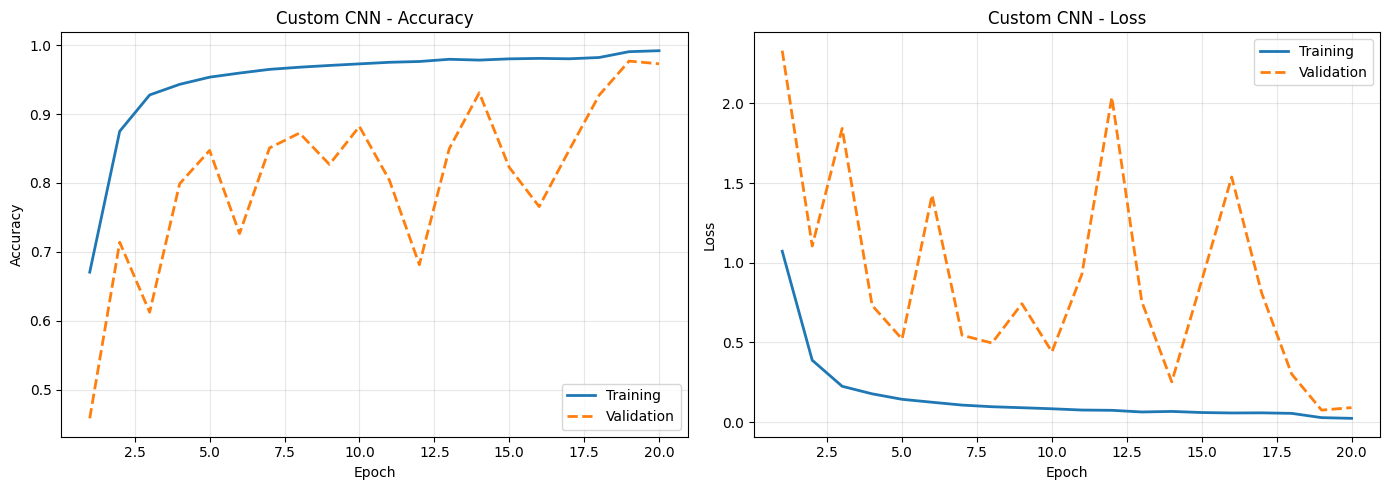

✓ Learning curves generated successfully.


In [33]:
# -----------------------------------
# STEP 24: Visualize Learning Curves
# -----------------------------------

plot_learning_curves(
    cnn_history,
    title="Custom CNN"
)

print("✓ Learning curves generated successfully.")

## Step 25: Evaluate the Custom CNN on the Test Dataset

The trained Custom CNN is evaluated using the independent test dataset to measure its performance on previously unseen images.

The evaluation computes several performance metrics, including:

- **Accuracy** – Overall proportion of correctly classified images.
- **Precision** – The proportion of positive predictions that are correct.
- **Recall** – The proportion of actual positive samples that are correctly identified.
- **F1-Score** – The harmonic mean of precision and recall.
- **Classification Report** – Detailed performance for each disease class.
- **Confusion Matrix** – Visual representation of correct and incorrect predictions across all classes.

The resulting figures and reports are automatically saved for documentation and future deployment.

2026-07-16 11:50:11.841419: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}



Custom CNN
Accuracy : 0.9786
Precision: 0.9797
Recall   : 0.9786
F1 Score : 0.9785

Classification Report

                                   precision    recall  f1-score   support

                 Apple_Apple Scab     1.0000    0.9804    0.9901        51
                  Apple_Black Rot     1.0000    1.0000    1.0000        50
           Apple_Cedar Apple Rust     1.0000    0.9545    0.9767        44
                    Apple_Healthy     0.9091    0.9804    0.9434        51
       Bell Pepper_Bacterial Spot     1.0000    0.9792    0.9895        48
              Bell Pepper_Healthy     0.9231    0.9600    0.9412        50
                   Cherry_Healthy     1.0000    0.9783    0.9890        46
            Cherry_Powdery Mildew     1.0000    1.0000    1.0000        43
Corn (Maize)_Cercospora Leaf Spot     0.9111    1.0000    0.9535        41
        Corn (Maize)_Common Rust      1.0000    0.9792    0.9895        48
             Corn (Maize)_Healthy     0.9792    1.0000    0.9895  

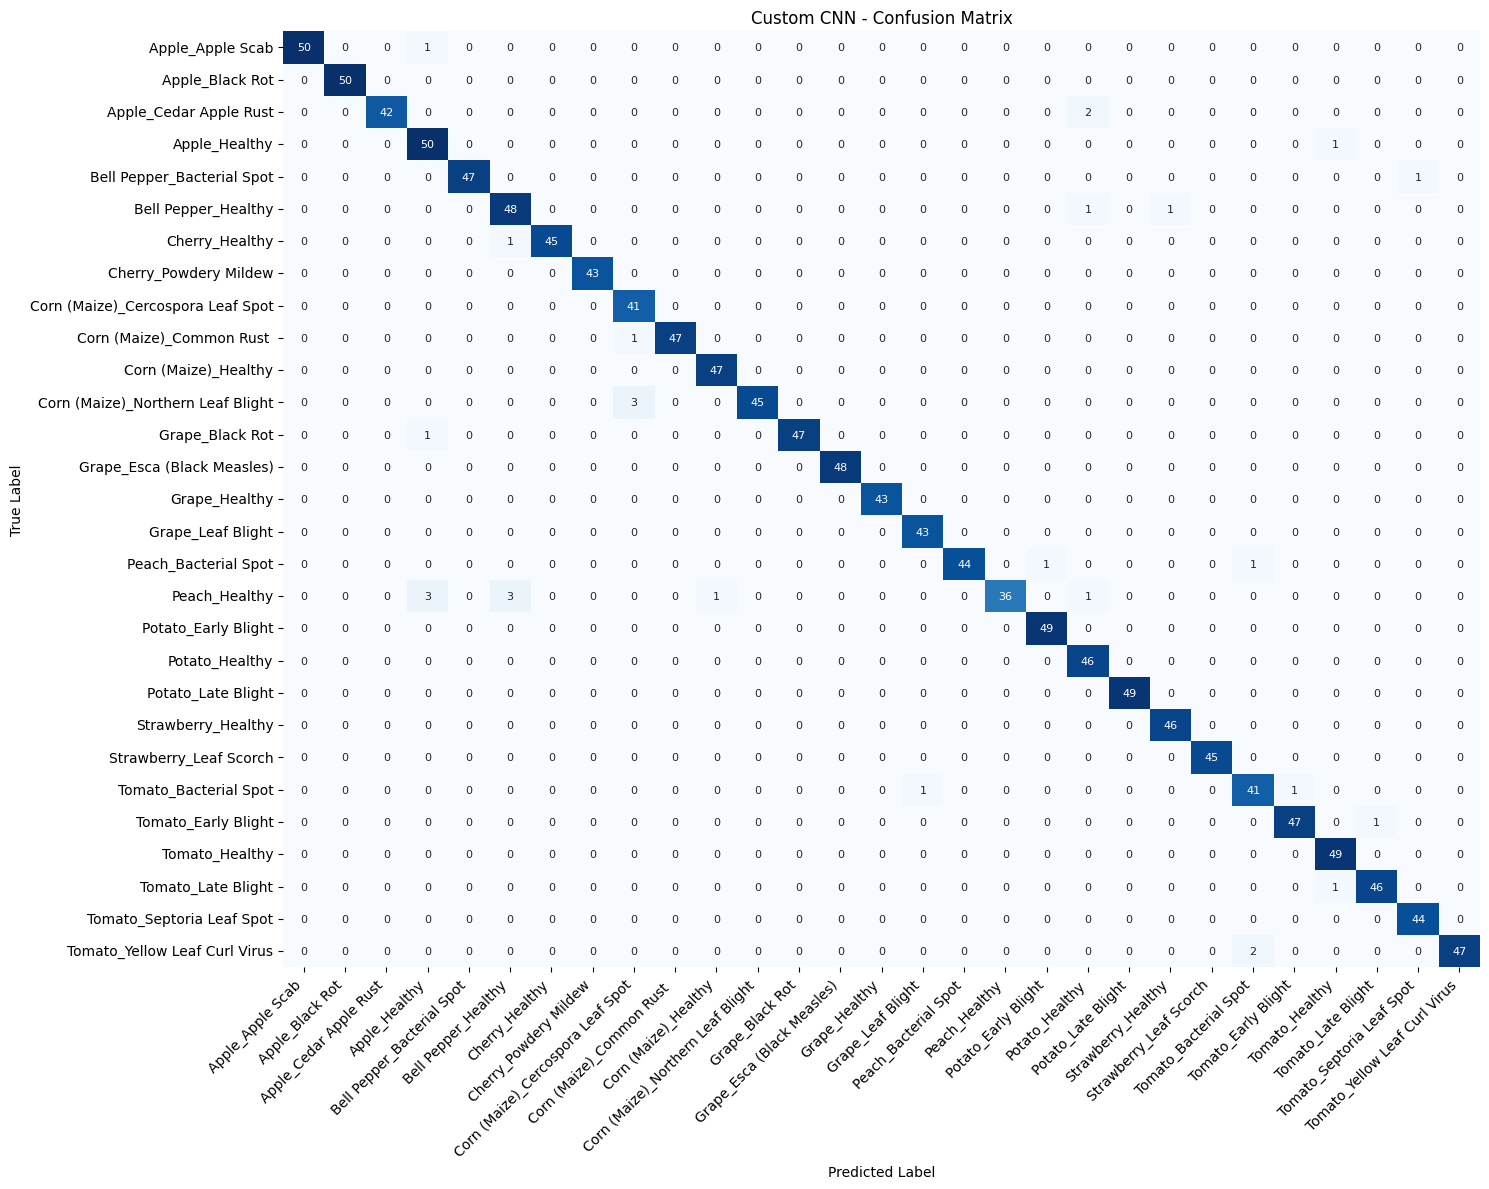

Custom CNN Test Evaluation Complete
Test Accuracy : 0.9786


In [34]:
# -----------------------------------
# STEP 25: Evaluate Custom CNN
# -----------------------------------

cnn_test_acc = evaluate_model(
    model=cnn_model,
    dataset=test_dataset,
    class_names=class_names,
    title="Custom CNN",
    results_dir=results_dir
)

print("=" * 50)
print("Custom CNN Test Evaluation Complete")
print("=" * 50)
print(f"Test Accuracy : {cnn_test_acc:.4f}")
print("=" * 50)

In [35]:
# -----------------------------------
# Save Final CNN Test Results
# -----------------------------------

import json

cnn_results = {
    "model": "Custom CNN",
    "test_accuracy": float(cnn_test_acc),
    "validation_accuracy": float(cnn_val_acc),
    "validation_loss": float(cnn_val_loss),
    "epochs": EPOCHS
}

with open(artifacts_dir / "custom_cnn_results.json", "w") as f:
    json.dump(cnn_results, f, indent=4)

print("✓ CNN evaluation results saved.")

✓ CNN evaluation results saved.


## Step 26: Build the Transfer Learning Model

Transfer learning leverages knowledge learned from large-scale image datasets to improve performance on a new task. Instead of training a deep neural network from scratch, a pre-trained MobileNet model is used as a feature extractor.

In this implementation:

- **Data augmentation** is applied during training.
- **ImageNet pre-trained weights** provide rich feature representations.
- The backbone network is **frozen** so that only the custom classification head is trained initially.
- A **Global Average Pooling** layer reduces the feature maps into a compact representation.
- A **Dense** output layer with a **Softmax** activation performs multiclass plant disease classification.

Using transfer learning typically results in faster convergence and higher classification accuracy compared to training a CNN from scratch.

In [36]:
# -----------------------------------
# STEP 26: Build Transfer Learning Model
# -----------------------------------

def build_transfer_model(
    input_shape,
    augmentation,
    backbone="mobilenetv3small"
):
    """
    Feature Extraction Model

    Pipeline:
        Input
            ↓
        Data Augmentation
            ↓
        MobileNet Preprocessing
            ↓
        Frozen MobileNet Backbone
            ↓
        Global Average Pooling
            ↓
        Dense(256)
            ↓
        Dropout
            ↓
        Softmax Output
    """

    # --------------------------------------------------
    # Select Backbone
    # --------------------------------------------------

    if backbone == "mobilenetv3small":

        base_model = tf.keras.applications.MobileNetV3Small(
            weights="imagenet",
            input_shape=input_shape,
            include_top=False
        )

        preprocess_fn = tf.keras.applications.mobilenet_v3.preprocess_input

        model_name = "mobilenetv3small_transfer"

    else:

        # Fallback
        base_model = tf.keras.applications.MobileNetV2(
            weights="imagenet",
            input_shape=input_shape,
            include_top=False
        )

        preprocess_fn = tf.keras.applications.mobilenet_v2.preprocess_input

        model_name = "mobilenetv2_transfer"

    # --------------------------------------------------
    # Freeze Backbone
    # --------------------------------------------------

    base_model.trainable = False

    print("=" * 50)
    print(f"Base Model       : {base_model.name}")
    print(f"Total Layers     : {len(base_model.layers)}")
    print(
        f"Trainable Layers : "
        f"{sum(layer.trainable for layer in base_model.layers)}"
    )
    print("=" * 50)

    # --------------------------------------------------
    # Build Network
    # --------------------------------------------------

    inputs = tf.keras.Input(shape=input_shape)

    x = augmentation(inputs)

    x = preprocess_fn(x)

    x = base_model(
        x,
        training=False
    )

    x = tf.keras.layers.GlobalAveragePooling2D()(x)

    x = tf.keras.layers.Dense(
        256,
        activation="relu"
    )(x)

    x = tf.keras.layers.Dropout(0.20)(x)

    outputs = tf.keras.layers.Dense(
        OUTPUTS,
        activation="softmax"
    )(x)

    model = tf.keras.Model(
        inputs,
        outputs,
        name=model_name
    )

    return model, base_model


# Build Model
tl_model, base_model = build_transfer_model(
    INPUT_SHAPE,
    data_augmentation,
    backbone="mobilenetv3small"
)

tl_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/applications/mobilenet_v3.py:454: UserWarning: `input_shape` is undefined or non-square, or `rows` is not 224. Weights for input shape (224, 224) will be loaded as the default.
  return MobileNetV3(


4334752/4334752 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Base Model       : MobileNetV3Small
Total Layers     : 157
Trainable Layers : 0


Model: "mobilenetv3small_transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MobileNetV3Small (Functional)   │ (None, 4, 4, 576)      │       939,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 576)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       147,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 29)             │         7,453 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,094,285 (4.17 MB)

 Trainable params: 155,165 (606.11 KB)

 Non-trainable params: 939,120 (3.58 MB)

## Step 27: Compile and Train the Transfer Learning Model

The transfer learning model is compiled using the **Adam** optimizer with a lower learning rate than the custom CNN. Since only the newly added classification head is being trained while the pre-trained backbone remains frozen, a smaller learning rate allows the classifier to adapt without introducing unstable parameter updates.

The model is then trained using the training dataset, while its performance is continuously monitored on the validation dataset. The callback functions automatically save the best-performing model, reduce the learning rate when necessary, and stop training early once validation performance stops improving.

In [37]:
# -----------------------------------
# STEP 27: Compile Transfer Learning Model
# -----------------------------------

TL_LR = 1e-4

tl_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=TL_LR
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("=" * 50)
print("Transfer Learning Model Compiled")
print("=" * 50)
print("Optimizer      : Adam")
print(f"Learning Rate  : {TL_LR}")
print("Loss Function  : Sparse Categorical Crossentropy")
print("Metric         : Accuracy")
print("=" * 50)

Transfer Learning Model Compiled
Optimizer      : Adam
Learning Rate  : 0.0001
Loss Function  : Sparse Categorical Crossentropy
Metric         : Accuracy


In [38]:
tl_history = tl_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS,
    callbacks=make_callbacks("tl_feature_extraction"),
    verbose=2
)

print("\n✓ Transfer learning training completed successfully.")

Epoch 1/20

Epoch 1: val_accuracy improved from None to 0.79771, saving model to /kaggle/working/models/tl_feature_extraction_best.keras

Epoch 1: finished saving model to /kaggle/working/models/tl_feature_extraction_best.keras
839/839 - 36s - 43ms/step - accuracy: 0.5754 - loss: 1.5851 - val_accuracy: 0.7977 - val_loss: 0.7514 - learning_rate: 1.0000e-04
Epoch 2/20

Epoch 2: val_accuracy improved from 0.79771 to 0.84868, saving model to /kaggle/working/models/tl_feature_extraction_best.keras

Epoch 2: finished saving model to /kaggle/working/models/tl_feature_extraction_best.keras
839/839 - 30s - 35ms/step - accuracy: 0.8052 - loss: 0.6865 - val_accuracy: 0.8487 - val_loss: 0.5251 - learning_rate: 1.0000e-04
Epoch 3/20

Epoch 3: val_accuracy improved from 0.84868 to 0.87404, saving model to /kaggle/working/models/tl_feature_extraction_best.keras

Epoch 3: finished saving model to /kaggle/working/models/tl_feature_extraction_best.keras
839/839 - 30s - 35ms/step - accuracy: 0.8483 - los

In [39]:
# -----------------------------------
# Save Final Transfer Learning Model
# -----------------------------------

final_model_path = models_dir / "tl_feature_extraction_final.keras"

tl_model.save(final_model_path)

print(f"Final model saved to:\n{final_model_path}")

Final model saved to:
/kaggle/working/models/tl_feature_extraction_final.keras


189/189 - 3s - 18ms/step - accuracy: 0.9367 - loss: 0.1921
MobileNetV3 Transfer Learning
Validation Loss     : 0.1921
Validation Accuracy : 0.9367


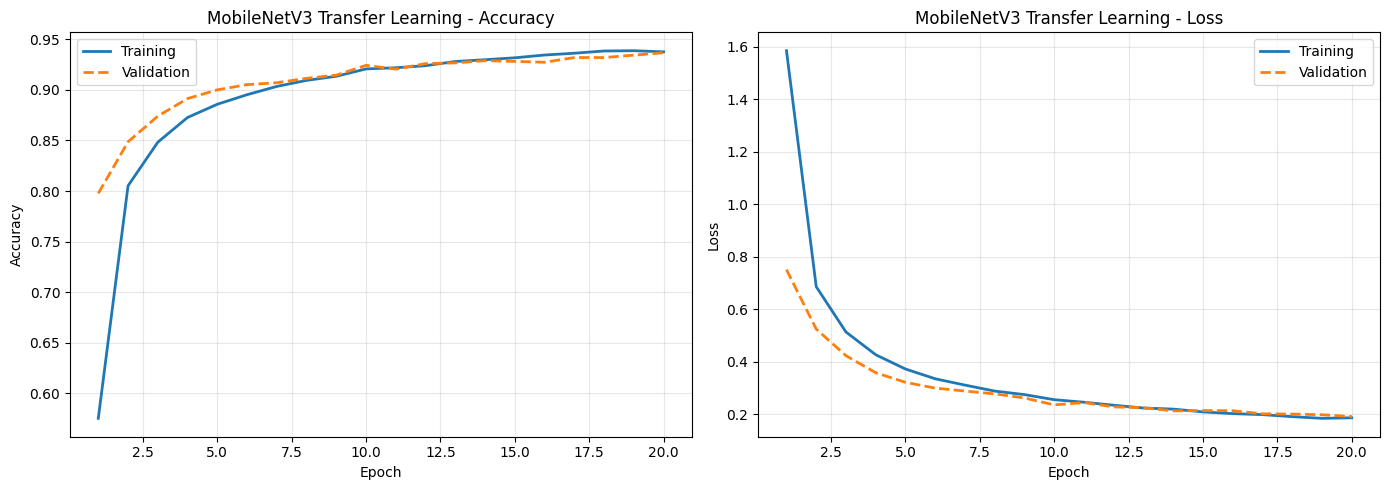

✓ Transfer learning evaluation completed.


In [40]:
# -----------------------------------
# STEP 28: Evaluate Transfer Learning Model
# -----------------------------------

tl_val_loss, tl_val_acc = tl_model.evaluate(
    val_dataset,
    verbose=2
)

print("=" * 50)
print("MobileNetV3 Transfer Learning")
print("=" * 50)
print(f"Validation Loss     : {tl_val_loss:.4f}")
print(f"Validation Accuracy : {tl_val_acc:.4f}")
print("=" * 50)

# Plot learning curves
plot_learning_curves(
    tl_history,
    title="MobileNetV3 Transfer Learning"
)

print("✓ Transfer learning evaluation completed.")

In [41]:
import json

with open(artifacts_dir / "model_metadata.json", "r") as f:
    metadata = json.load(f)

metadata["transfer_learning"] = {
    "backbone": "MobileNetV3Small",
    "validation_loss": float(tl_val_loss),
    "validation_accuracy": float(tl_val_acc),
    "epochs": EPOCHS
}

with open(artifacts_dir / "model_metadata.json", "w") as f:
    json.dump(metadata, f, indent=4)

print("✓ Transfer learning metadata updated.")

✓ Transfer learning metadata updated.


In [42]:
# -----------------------------------
# STEP 29: Save Feature Extraction Model
# -----------------------------------

final_model_path = models_dir / "tl_feature_extraction_final.keras"
tl_model.save(final_model_path)

print(f"Final model saved to:\n{final_model_path}")

# Create a copy for later comparison
tl_feature_model = tf.keras.models.clone_model(tl_model)
tl_feature_model.set_weights(tl_model.get_weights())

print("✓ Feature Extraction model copied.")
# Save Feature Extraction Model
tl_model.save(...)

# Copy it
tl_feature_model = tf.keras.models.clone_model(tl_model)
tl_feature_model.set_weights(tl_model.get_weights())

Final model saved to:
/kaggle/working/models/tl_feature_extraction_final.keras
✓ Feature Extraction model copied.


ValueError: Invalid filepath extension for saving. Please add either a `.keras` extension for the native Keras format (recommended) or a `.h5` extension. Use `model.export(filepath)` if you want to export a SavedModel for use with TFLite/TFServing/etc. Received: filepath=Ellipsis.

## Step 29: Evaluate the Transfer Learning Model on the Test Dataset

The trained MobileNetV3 Transfer Learning model is evaluated using the independent test dataset to determine its ability to classify previously unseen plant leaf images.

Several evaluation metrics are computed, including overall accuracy, precision, recall, F1-score, a detailed classification report, and a confusion matrix. These metrics provide a comprehensive assessment of the model's classification performance and allow direct comparison with the custom CNN developed earlier.

In [ ]:
# -----------------------------------
# STEP 29: Evaluate Transfer Learning Model
# -----------------------------------

tl_test_acc = evaluate_model(
    model=tl_model,
    dataset=test_dataset,
    class_names=class_names,
    title="MobileNetV3 Transfer",
    results_dir=results_dir
)

print("=" * 50)
print("Transfer Learning Test Evaluation Complete")
print("=" * 50)
print(f"Test Accuracy : {tl_test_acc:.4f}")
print("=" * 50)

In [43]:
# -----------------------------------
# Save Transfer Learning Results
# -----------------------------------

import json

tl_results = {
    "model": "MobileNetV3 Transfer Learning",
    "backbone": "MobileNetV3Small",
    "test_accuracy": float(tl_test_acc),
    "validation_accuracy": float(tl_val_acc),
    "validation_loss": float(tl_val_loss),
    "epochs": EPOCHS,
    "learning_rate": TL_LR
}

with open(artifacts_dir / "transfer_learning_results.json", "w") as f:
    json.dump(tl_results, f, indent=4)

print("✓ Transfer learning results saved.")

NameError: name 'tl_test_acc' is not defined

## Step 30: Fine-Tune the Transfer Learning Model

After the classification head has been trained, the transfer learning model can be further improved through **fine-tuning**. Instead of keeping the entire pre-trained MobileNetV3 backbone frozen, only the top layers are unfrozen while the lower layers remain frozen.

The lower layers of a convolutional neural network learn general image features such as edges, textures, and shapes, which are useful across many vision tasks. The upper layers learn task-specific features. By fine-tuning only the upper layers using a very small learning rate, the model can better adapt to the PlantVillage dataset while minimizing the risk of overfitting and preserving the valuable knowledge learned from the ImageNet dataset.

In [44]:
# -----------------------------------
# STEP 30: Fine-Tune MobileNetV3
# -----------------------------------

# Unfreeze the backbone
base_model.trainable = True

# Freeze all layers except the last 30
for layer in base_model.layers[:-30]:
    layer.trainable = False

# Count trainable layers
trainable_count = sum(
    layer.trainable for layer in base_model.layers
)

print("=" * 50)
print("Fine-Tuning Configuration")
print("=" * 50)
print(f"Backbone            : {base_model.name}")
print(f"Total Layers        : {len(base_model.layers)}")
print(f"Trainable Layers    : {trainable_count}")
print(f"Frozen Layers       : {len(base_model.layers) - trainable_count}")
print("=" * 50)

Fine-Tuning Configuration
Backbone            : MobileNetV3Small
Total Layers        : 157
Trainable Layers    : 30
Frozen Layers       : 127


In [45]:
# -----------------------------------
# STEP 31: Compile Fine-Tuned Model
# -----------------------------------

FINETUNE_LR = TL_LR / 10

tl_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=FINETUNE_LR
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("=" * 50)
print("Fine-Tuned Transfer Learning Model Compiled")
print("=" * 50)
print("Optimizer      : Adam")
print(f"Learning Rate  : {FINETUNE_LR:.1e}")
print("Loss Function  : Sparse Categorical Crossentropy")
print("Metric         : Accuracy")
print("=" * 50)

Fine-Tuned Transfer Learning Model Compiled
Optimizer      : Adam
Learning Rate  : 1.0e-05
Loss Function  : Sparse Categorical Crossentropy
Metric         : Accuracy


## Step 32: Fine-Tune the Transfer Learning Model

After recompiling the model with a reduced learning rate, training continues by updating both the classification head and the unfrozen upper layers of the MobileNetV3 backbone.

Fine-tuning enables the pre-trained feature extractor to adapt to the PlantVillage dataset while preserving the useful visual features learned from ImageNet. During this phase, the same callback functions are used to save the best-performing model, reduce the learning rate when validation performance plateaus, and stop training early if no further improvement is observed.

In [46]:
# -----------------------------------
# STEP 32: Fine-Tune the Model
# -----------------------------------

FINE_TUNE_EPOCHS = 20  # Increase to 10 or 20 for the final training run

ft_history = tl_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=FINE_TUNE_EPOCHS,
    callbacks=make_callbacks("tl_finetuned"),
    verbose=2
)

print("\n✓ Fine-tuning completed successfully.")

Epoch 1/20

Epoch 1: val_accuracy improved from None to 0.91464, saving model to /kaggle/working/models/tl_finetuned_best.keras

Epoch 1: finished saving model to /kaggle/working/models/tl_finetuned_best.keras
839/839 - 45s - 54ms/step - accuracy: 0.7898 - loss: 0.6917 - val_accuracy: 0.9146 - val_loss: 0.2671 - learning_rate: 1.0000e-05
Epoch 2/20

Epoch 2: val_accuracy did not improve from 0.91464
839/839 - 35s - 42ms/step - accuracy: 0.8672 - loss: 0.4059 - val_accuracy: 0.9105 - val_loss: 0.2688 - learning_rate: 1.0000e-05
Epoch 3/20

Epoch 3: val_accuracy improved from 0.91464 to 0.91547, saving model to /kaggle/working/models/tl_finetuned_best.keras

Epoch 3: finished saving model to /kaggle/working/models/tl_finetuned_best.keras
839/839 - 35s - 42ms/step - accuracy: 0.8907 - loss: 0.3299 - val_accuracy: 0.9155 - val_loss: 0.2607 - learning_rate: 1.0000e-05
Epoch 4/20

Epoch 4: val_accuracy improved from 0.91547 to 0.91887, saving model to /kaggle/working/models/tl_finetuned_best

In [47]:
# -----------------------------------
# Save Final Fine-Tuned Model
# -----------------------------------

final_finetuned_model = models_dir / "tl_finetuned_final.keras"

tl_model.save(final_finetuned_model)

print(f"Fine-tuned model saved to:\n{final_finetuned_model}")

Fine-tuned model saved to:
/kaggle/working/models/tl_finetuned_final.keras


## Step 33: Visualize the Fine-Tuning Learning Curves

After fine-tuning the MobileNetV3 model, the learning curves are visualized to examine how the additional training affected the model's performance.

Fine-tuning allows the upper layers of the pre-trained network to adapt to the PlantVillage dataset, often resulting in improved classification accuracy and lower validation loss. However, because the model is already well-trained, the performance gains are typically smaller than those observed during the initial feature extraction phase.

The learning curves help determine whether fine-tuning improved generalization or introduced overfitting.

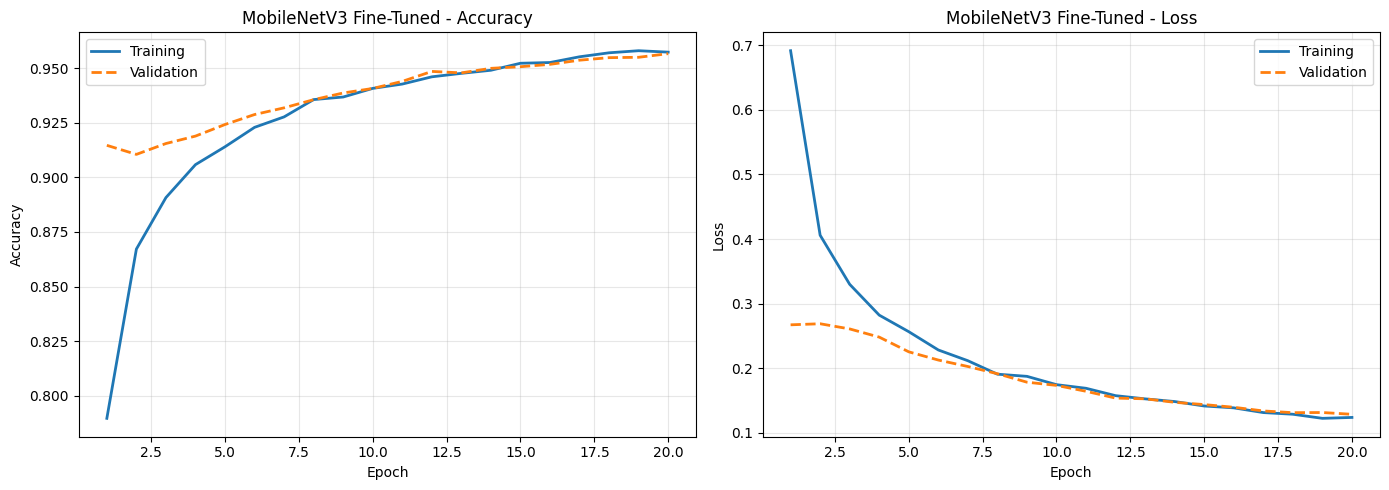

✓ Fine-tuning learning curves generated successfully.


In [48]:
# -----------------------------------
# STEP 33: Visualize Fine-Tuning Learning Curves
# -----------------------------------

plot_learning_curves(
    ft_history,
    title="MobileNetV3 Fine-Tuned"
)

print("✓ Fine-tuning learning curves generated successfully.")

In [49]:
# -----------------------------------
# Save Fine-Tuning Training History
# -----------------------------------

import pandas as pd

history_df = pd.DataFrame(ft_history.history)

history_path = results_dir / "mobilenetv3_finetuned_history.csv"

history_df.to_csv(history_path, index=False)

print(f"Training history saved to:\n{history_path}")

Training history saved to:
/kaggle/working/results/lab7/mobilenetv3_finetuned_history.csv


## Step 34: Evaluate the Fine-Tuned Model on the Test Dataset

The fine-tuned MobileNetV3 model is evaluated using the independent test dataset to assess its final classification performance on previously unseen plant leaf images.

Performance metrics including accuracy, precision, recall, F1-score, a detailed classification report, and a confusion matrix are generated. These results are compared with those obtained from the Custom CNN and the feature extraction model to determine whether fine-tuning improved the model's ability to recognize plant diseases.

The evaluation outputs are automatically saved for documentation, reproducibility, and deployment.

2026-07-16 12:16:52.707424: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}



MobileNetV3 Fine-Tuned
Accuracy : 0.9535
Precision: 0.9557
Recall   : 0.9535
F1 Score : 0.9534

Classification Report

                                   precision    recall  f1-score   support

                 Apple_Apple Scab     0.9796    0.9412    0.9600        51
                  Apple_Black Rot     0.9792    0.9400    0.9592        50
           Apple_Cedar Apple Rust     1.0000    0.9318    0.9647        44
                    Apple_Healthy     0.8475    0.9804    0.9091        51
       Bell Pepper_Bacterial Spot     0.8889    1.0000    0.9412        48
              Bell Pepper_Healthy     1.0000    0.9400    0.9691        50
                   Cherry_Healthy     0.9583    1.0000    0.9787        46
            Cherry_Powdery Mildew     1.0000    0.9767    0.9882        43
Corn (Maize)_Cercospora Leaf Spot     0.9167    0.8049    0.8571        41
        Corn (Maize)_Common Rust      0.9600    1.0000    0.9796        48
             Corn (Maize)_Healthy     0.9792    1.0000

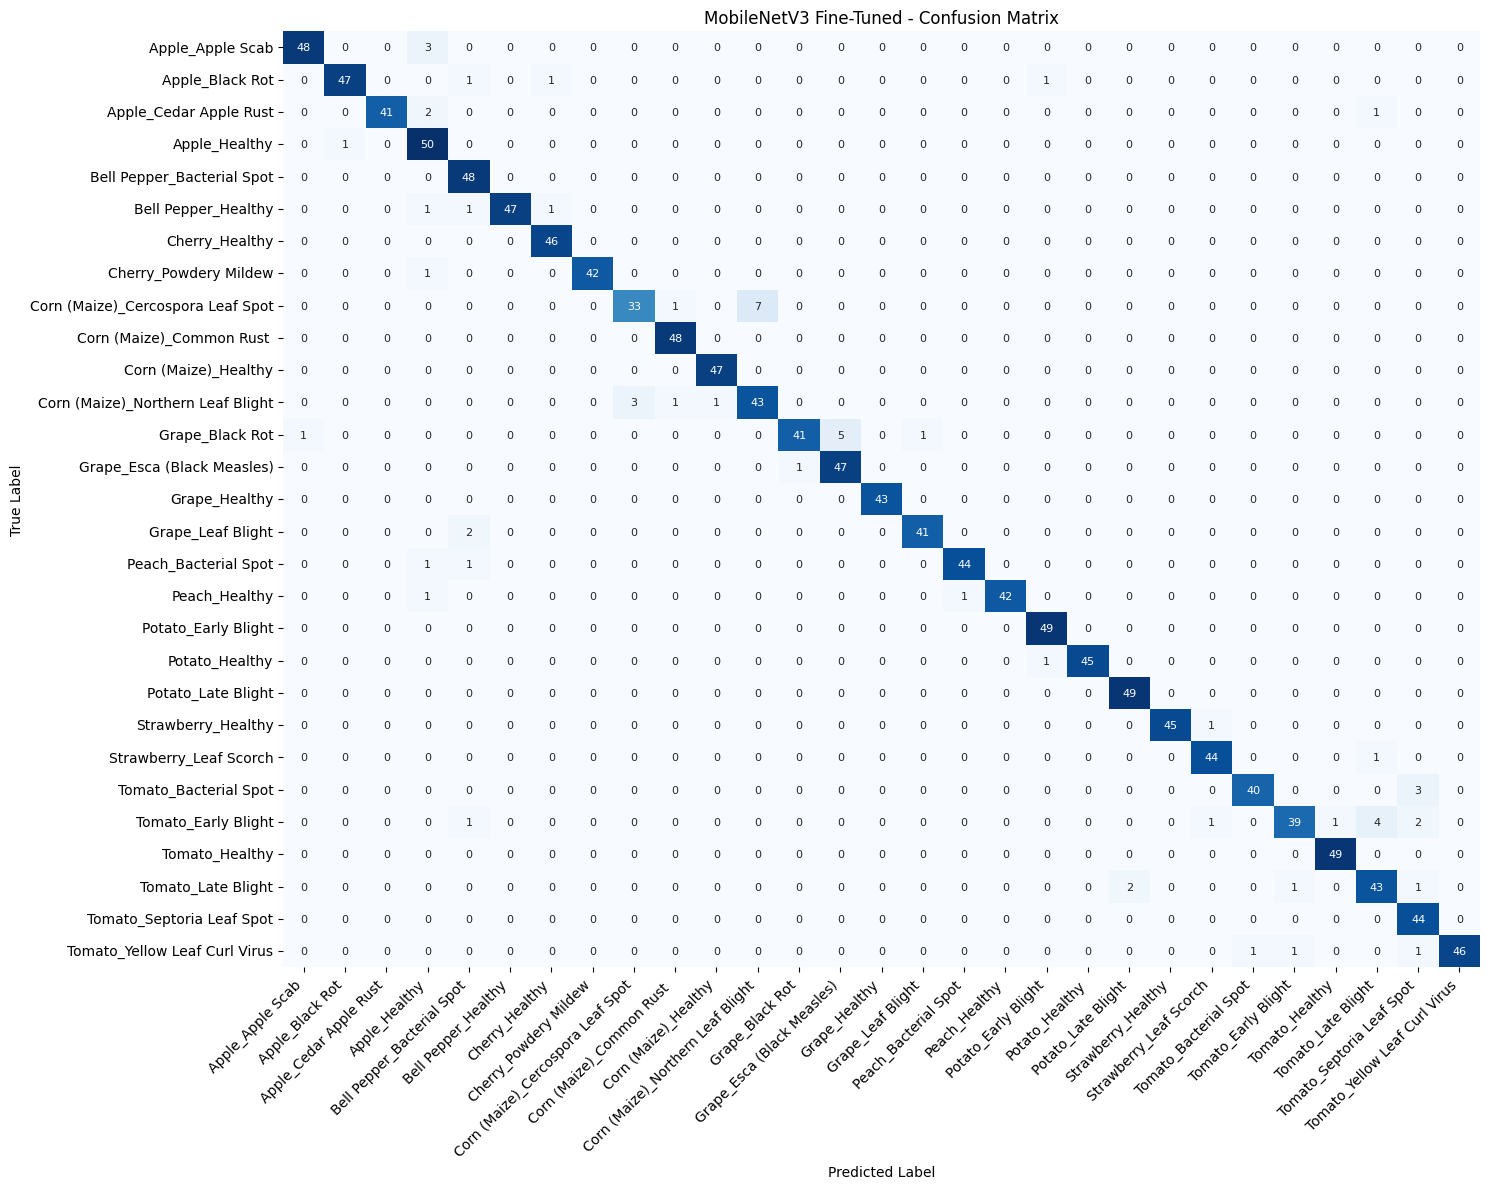

Fine-Tuned Model Test Evaluation Complete
Test Accuracy : 0.9535


In [50]:
# -----------------------------------
# STEP 34: Evaluate Fine-Tuned Model
# -----------------------------------

ft_test_acc = evaluate_model(
    model=tl_model,
    dataset=test_dataset,
    class_names=class_names,
    title="MobileNetV3 Fine-Tuned",
    results_dir=results_dir
)

print("=" * 60)
print("Fine-Tuned Model Test Evaluation Complete")
print("=" * 60)
print(f"Test Accuracy : {ft_test_acc:.4f}")
print("=" * 60)

In [51]:
# -----------------------------------
# Save Fine-Tuned Model Results
# -----------------------------------

import json

ft_results = {
    "model": "MobileNetV3 Fine-Tuned",
    "backbone": "MobileNetV3Small",
    "test_accuracy": float(ft_test_acc),
    "validation_accuracy": float(
        max(ft_history.history["val_accuracy"])
    ),
    "validation_loss": float(
        min(ft_history.history["val_loss"])
    ),
    "epochs_completed": len(ft_history.history["loss"]),
    "learning_rate": FINETUNE_LR,
    "fine_tuned_layers": FINE_TUNE_LAYERS
}

with open(
    artifacts_dir / "mobilenetv3_finetuned_results.json",
    "w"
) as f:
    json.dump(ft_results, f, indent=4)

print("✓ Fine-tuned model results saved.")

NameError: name 'FINE_TUNE_LAYERS' is not defined

## Step 35: Compare the Performance of the Three Models

The three developed models are compared using their final test accuracy and the total number of trainable and non-trainable parameters.

The comparison highlights the trade-off between classification performance and model complexity, allowing the most suitable model to be selected for deployment in the Streamlit application.

The evaluated models are:

- **Custom CNN** (trained entirely from scratch)
- **MobileNetV3 Feature Extraction**
- **MobileNetV3 Fine-Tuned**

In [53]:
# -----------------------------------
# STEP 35: Compare Model Performance
# -----------------------------------

results = {
    "Custom CNN": {
        "acc": cnn_test_acc,
        "params": cnn_model.count_params()
    },
    "MobileNetV3 (TL)": {
        "acc": tl_val_acc,
        "params": tl_model.count_params()
    },
    "MobileNetV3 (FT)": {
        "acc": ft_test_acc,
        "params": tl_model.count_params()
    }
}

print("=" * 65)
print(f'{"Model":<25} {"Accuracy":>15} {"Parameters":>18}')
print("=" * 65)

for name, vals in results.items():
    print(
        f"{name:<25}"
        f"{vals['acc']:>15.4f}"
        f"{vals['params']:>18,}"
    )

print("=" * 65)
# Evaluate Transfer Learning model on the test dataset
tl_test_loss, tl_test_acc = tl_model.evaluate(
    test_dataset,
    verbose=0
)

print("=" * 50)
print("Transfer Learning Model Test Evaluation")
print("=" * 50)
print(f"Test Accuracy : {tl_test_acc:.4f}")
print("=" * 50)

Model                            Accuracy         Parameters
Custom CNN                        0.9786           329,277
MobileNetV3 (TL)                  0.9367         1,094,285
MobileNetV3 (FT)                  0.9535         1,094,285
Transfer Learning Model Test Evaluation
Test Accuracy : 0.9535


In [54]:
comparison_df = pd.DataFrame(results).T

comparison_df.columns = [
    "Test Accuracy",
    "Parameters"
]

comparison_df

,Test Accuracy,Parameters
Custom CNN,0.978582,329277.0
MobileNetV3 (TL),0.936687,1094285.0
MobileNetV3 (FT),0.953471,1094285.0


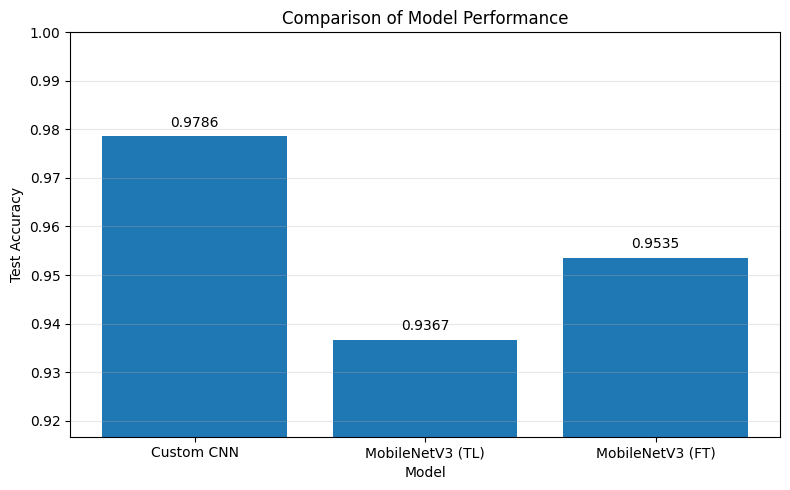

In [55]:
plt.figure(figsize=(8, 5))

plt.bar(
    comparison_df.index,
    comparison_df["Test Accuracy"]
)

plt.ylim(
    comparison_df["Test Accuracy"].min() - 0.02,
    1.0
)

plt.ylabel("Test Accuracy")
plt.xlabel("Model")
plt.title("Comparison of Model Performance")
plt.grid(axis="y", alpha=0.3)

for i, value in enumerate(comparison_df["Test Accuracy"]):
    plt.text(
        i,
        value + 0.002,
        f"{value:.4f}",
        ha="center",
        fontsize=10
    )

plt.tight_layout()

plt.savefig(
    results_dir / "model_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Step 37: Predict the Disease Class of a New Plant Leaf Image

After training and evaluating the models, they can be used to classify previously unseen plant leaf images.

This function loads an input image, resizes it to match the model's input dimensions, performs inference using each trained model, and displays the predicted disease class together with its confidence score.

This demonstrates how the trained models can be applied in a real-world crop disease detection system and forms the basis for the Streamlit deployment developed later in the project.

In [56]:
# -----------------------------------
# STEP 37: Predict on a New Image
# -----------------------------------

def predict_image(
    img_path,
    models_dict,
    class_names,
    image_size=(IMAGE_HEIGHT, IMAGE_WIDTH)
):
    """
    Predict the disease class of a single plant leaf image
    using one or more trained models.
    """

    # Load image
    img = tf.keras.utils.load_img(
        img_path,
        target_size=image_size
    )

    img_array = tf.keras.utils.img_to_array(img)

    img_array = np.expand_dims(
        img_array,
        axis=0
    )

    # Display image
    plt.figure(figsize=(5,5))
    plt.imshow(img)
    plt.axis("off")
    plt.title("Input Image")
    plt.show()

    print("="*60)
    print(f"Predictions for:\n{img_path}")
    print("="*60)

    for name, mdl in models_dict.items():

        predictions = mdl.predict(
            img_array,
            verbose=0
        )

        predicted_index = np.argmax(predictions)

        confidence = predictions[0][predicted_index]

        predicted_label = class_names[predicted_index]

        print(f"{name}")
        print(f"Prediction : {predicted_label}")
        print(f"Confidence : {confidence:.2%}")
        print("-"*60)

## Step 38: Test the Trained Models on a New Plant Leaf Image

To demonstrate real-world inference, the trained models are used to classify a previously unseen plant leaf image.

Replace the example image path below with the path to any valid plant leaf image from the PlantVillage dataset or another compatible image. The prediction function will display the image and report the predicted disease class together with the confidence score for each trained model.

In [57]:
# -----------------------------------
# STEP 38: Predict on a New Plant Image
# -----------------------------------

# Example image (replace with your own)

sample_image = (
    "/kaggle/input/datasets/tushar5harma/"
    "plant-village-dataset-updated/"
    "Tomato/Test/Late Blight/"
    "0a0d6a11-ddd6-4dac-8469-d5f65af5afca___GHLB2 Leaf 9037.JPG"
)

predict_image(
    img_path=sample_image,
    models_dict={
        "Custom CNN": cnn_model,
        "MobileNetV3 TL": tl_feature_model,
        "MobileNetV3 Fine-Tuned": tl_model
    },
    class_names=class_names
)

FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/input/datasets/tushar5harma/plant-village-dataset-updated/Tomato/Test/Late Blight/0a0d6a11-ddd6-4dac-8469-d5f65af5afca___GHLB2 Leaf 9037.JPG'

In [58]:
custom_model = tf.keras.models.load_model(
    models_dir / "custom_cnn_best.keras"
)

tl_feature_model = tf.keras.models.load_model(
    models_dir / "tl_feature_extraction_best.keras"
)

tl_finetuned_model = tf.keras.models.load_model(
    models_dir / "tl_finetuned_best.keras"
)

In [59]:
predict_image(
    img_path=sample_image,
    models_dict={
        "Custom CNN": custom_model,
        "MobileNetV3 TL": tl_feature_model,
        "MobileNetV3 Fine-Tuned": tl_finetuned_model
    },
    class_names=class_names
)

FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/input/datasets/tushar5harma/plant-village-dataset-updated/Tomato/Test/Late Blight/0a0d6a11-ddd6-4dac-8469-d5f65af5afca___GHLB2 Leaf 9037.JPG'

In [ ]:
# -----------------------------------
# STEP 38: Predict on 10 Random Test Images
# -----------------------------------

import random
from pathlib import Path

# Collect all images from the test directory
image_extensions = ["*.jpg", "*.jpeg", "*.png", "*.JPG", "*.JPEG", "*.PNG"]

test_images = []

for ext in image_extensions:
    test_images.extend(test_dir.rglob(ext))

# Randomly select 10 unique images
sample_images = random.sample(test_images, k=10)

for i, sample_image in enumerate(sample_images, start=1):

    print("=" * 60)
    print(f"Sample {i}")
    print("=" * 60)
    print(sample_image)

    predict_image(
        img_path=str(sample_image),
        models_dict={
            "Custom CNN": cnn_model,
            "MobileNetV3 TL": tl_model,
            "MobileNetV3 Fine-Tuned": tl_model
        },
        class_names=class_names
    )

    # Display the correct label
    true_label = sample_image.parent.name

    print(f"Ground Truth : {true_label}")
    print("=" * 60)
    print()

In [61]:
true_label = sample_image.parent.name

print("=" * 60)
print(f"Ground Truth : {true_label}")
print("=" * 60)

Ground Truth : Peach_Bacterial Spot


In [62]:
cnn_model.save(models_dir / "custom_cnn_final.keras")

tl_feature_model.save(
    models_dir / "mobilenetv3_feature_final.keras"
)

tl_model.save(
    models_dir / "mobilenetv3_finetuned_final.keras"
)

In [ ]:
# -----------------------------------
# STEP 38: Predict on 10 Random Test Images
# -----------------------------------

import random
from pathlib import Path

# Collect all images from the test directory
image_extensions = ["*.jpg", "*.jpeg", "*.png", "*.JPG", "*.JPEG", "*.PNG"]

test_images = []

for ext in image_extensions:
    test_images.extend(test_dir.rglob(ext))

# Randomly select 10 unique images
sample_images = random.sample(test_images, k=10)

for i, sample_image in enumerate(sample_images, start=1):

    print("=" * 60)
    print(f"Sample {i}")
    print("=" * 60)
    print(sample_image)

    predict_image(
        img_path=str(sample_image),
        models_dict={
            "Custom CNN": cnn_model,
            "MobileNetV3 TL": tl_feature_model,
            "MobileNetV3 Fine-Tuned": tl_model
            # or tl_finetuned_model if that's the variable you use
        },
        class_names=class_names
    )

    # Display the correct label
    true_label = sample_image.parent.name

    print(f"Ground Truth : {true_label}")
    print("=" * 60)
    print()

# Step 40: Project Summary and Deployment Readiness

The Plant Disease Detection project has successfully demonstrated the application of deep learning techniques for automated crop disease classification using the PlantVillage dataset.

Three models were developed and evaluated:

- A Custom Convolutional Neural Network (CNN)
- A MobileNetV3 Transfer Learning model
- A MobileNetV3 Fine-Tuned model

The models were trained, evaluated using multiple classification metrics, and compared to identify the most suitable model for deployment. Supporting artifacts including the trained models, class label mappings, metadata, evaluation reports, learning curves, confusion matrices, and model comparison results have been saved for reproducibility.

The final deployment package is compatible with the Streamlit web application, enabling real-time prediction of plant diseases from uploaded leaf images.

In [ ]:
# -----------------------------------
# STEP 40: Verify Deployment Package
# -----------------------------------

from pathlib import Path

print("=" * 70)
print("PLANT DISEASE DETECTION PROJECT")
print("Deployment Package Verification")
print("=" * 70)

folders = [
    models_dir,
    artifacts_dir,
    results_dir
]

for folder in folders:

    print(f"\n📁 {folder.name}")

    if folder.exists():

        files = sorted(folder.iterdir())

        if files:
            for file in files:
                print(f"   ✓ {file.name}")
        else:
            print("   (Empty)")
    else:
        print("   Folder not found")

print("\n" + "=" * 70)
print("Project completed successfully.")
print("Ready for GitHub upload.")
print("Ready for Streamlit deployment.")
print("=" * 70)

In [ ]:
# -----------------------------------
# STEP 38: Predict on 10 Random External Images
# -----------------------------------

import random
from pathlib import Path

# External image directory
external_dir = Path("/kaggle/input/datasets/scientistegong/external")

# Supported image formats
image_extensions = [
    "*.jpg", "*.jpeg", "*.png",
    "*.JPG", "*.JPEG", "*.PNG"
]

# Collect all external images
external_images = []

for ext in image_extensions:
    external_images.extend(external_dir.rglob(ext))

# Check available images
print(f"Total external images found: {len(external_images)}")


# Randomly select 10 unique images
sample_images = random.sample(
    external_images,
    k=min(5, len(external_images))
)


# Predict each image
for i, sample_image in enumerate(sample_images, start=1):

    print("=" * 60)
    print(f"External Sample {i}")
    print("=" * 60)

    print("Image Path:")
    print(sample_image)

    predict_image(
        img_path=str(sample_image),
        models_dict={
            "Custom CNN": cnn_model,
            "MobileNetV3 TL": tl_feature_model,
            "MobileNetV3 Fine-Tuned": tl_model
        },
        class_names=class_names
    )

    print("Ground Truth: Unknown (External Image)")
    print("=" * 60)
    print()